# 🧪 QSAR Fish Toxicity Project
**Complete 23-Step Pipeline with Evaluation Rubric Mapping**

  
**Dataset Used**:`qsar_fish_toxicity.csv`  
 **Objective:** Predict LC50 toxicity of chemicals using machine learning with full analysis and model development pipeline  
 **Rubric Target:** Score Level 8-10 – Advanced exploration, insightful EDA, and ensemble techniques  


In [ ]:
# Step 1: Importing Libraries
!pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
print(" Libraries imported.")

In [15]:
# Step 2 & 3: Upload and Explore Dataset
df = pd.read_csv("qsar_fish_toxicity.csv")
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CIC0                906 non-null    float64
 1   SM1_Dz(Z)           906 non-null    float64
 2   GATS1i              906 non-null    float64
 3   NdsCH               907 non-null    float64
 4   NdssC               908 non-null    int64  
 5   MLOGP               905 non-null    float64
 6   LC50 [-LOG(mol/L)]  906 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 49.8 KB


None

,CIC0,SM1_Dz(Z),GATS1i,NdsCH,NdssC,MLOGP,LC50 [-LOG(mol/L)]
count,906.000000,906.000000,906.000000,907.000000,908.000000,905.000000,906.000000
mean,2.898620,0.628595,1.297135,0.229327,0.504405,2.113989,4.063213
std,0.756221,0.428775,0.412765,0.605621,1.083596,1.480015,1.457018
min,0.667000,0.000000,0.396000,0.000000,-3.000000,-5.780000,0.053000
25%,2.348750,0.223000,0.950250,0.000000,0.000000,1.209000,3.151250
50%,2.934000,0.570000,1.240500,0.000000,0.000000,2.127000,3.984000
75%,3.407000,0.896250,1.562750,0.000000,1.000000,3.109000,4.910500
max,5.926000,2.171000,4.980000,4.000000,20.000000,10.000000,9.612000


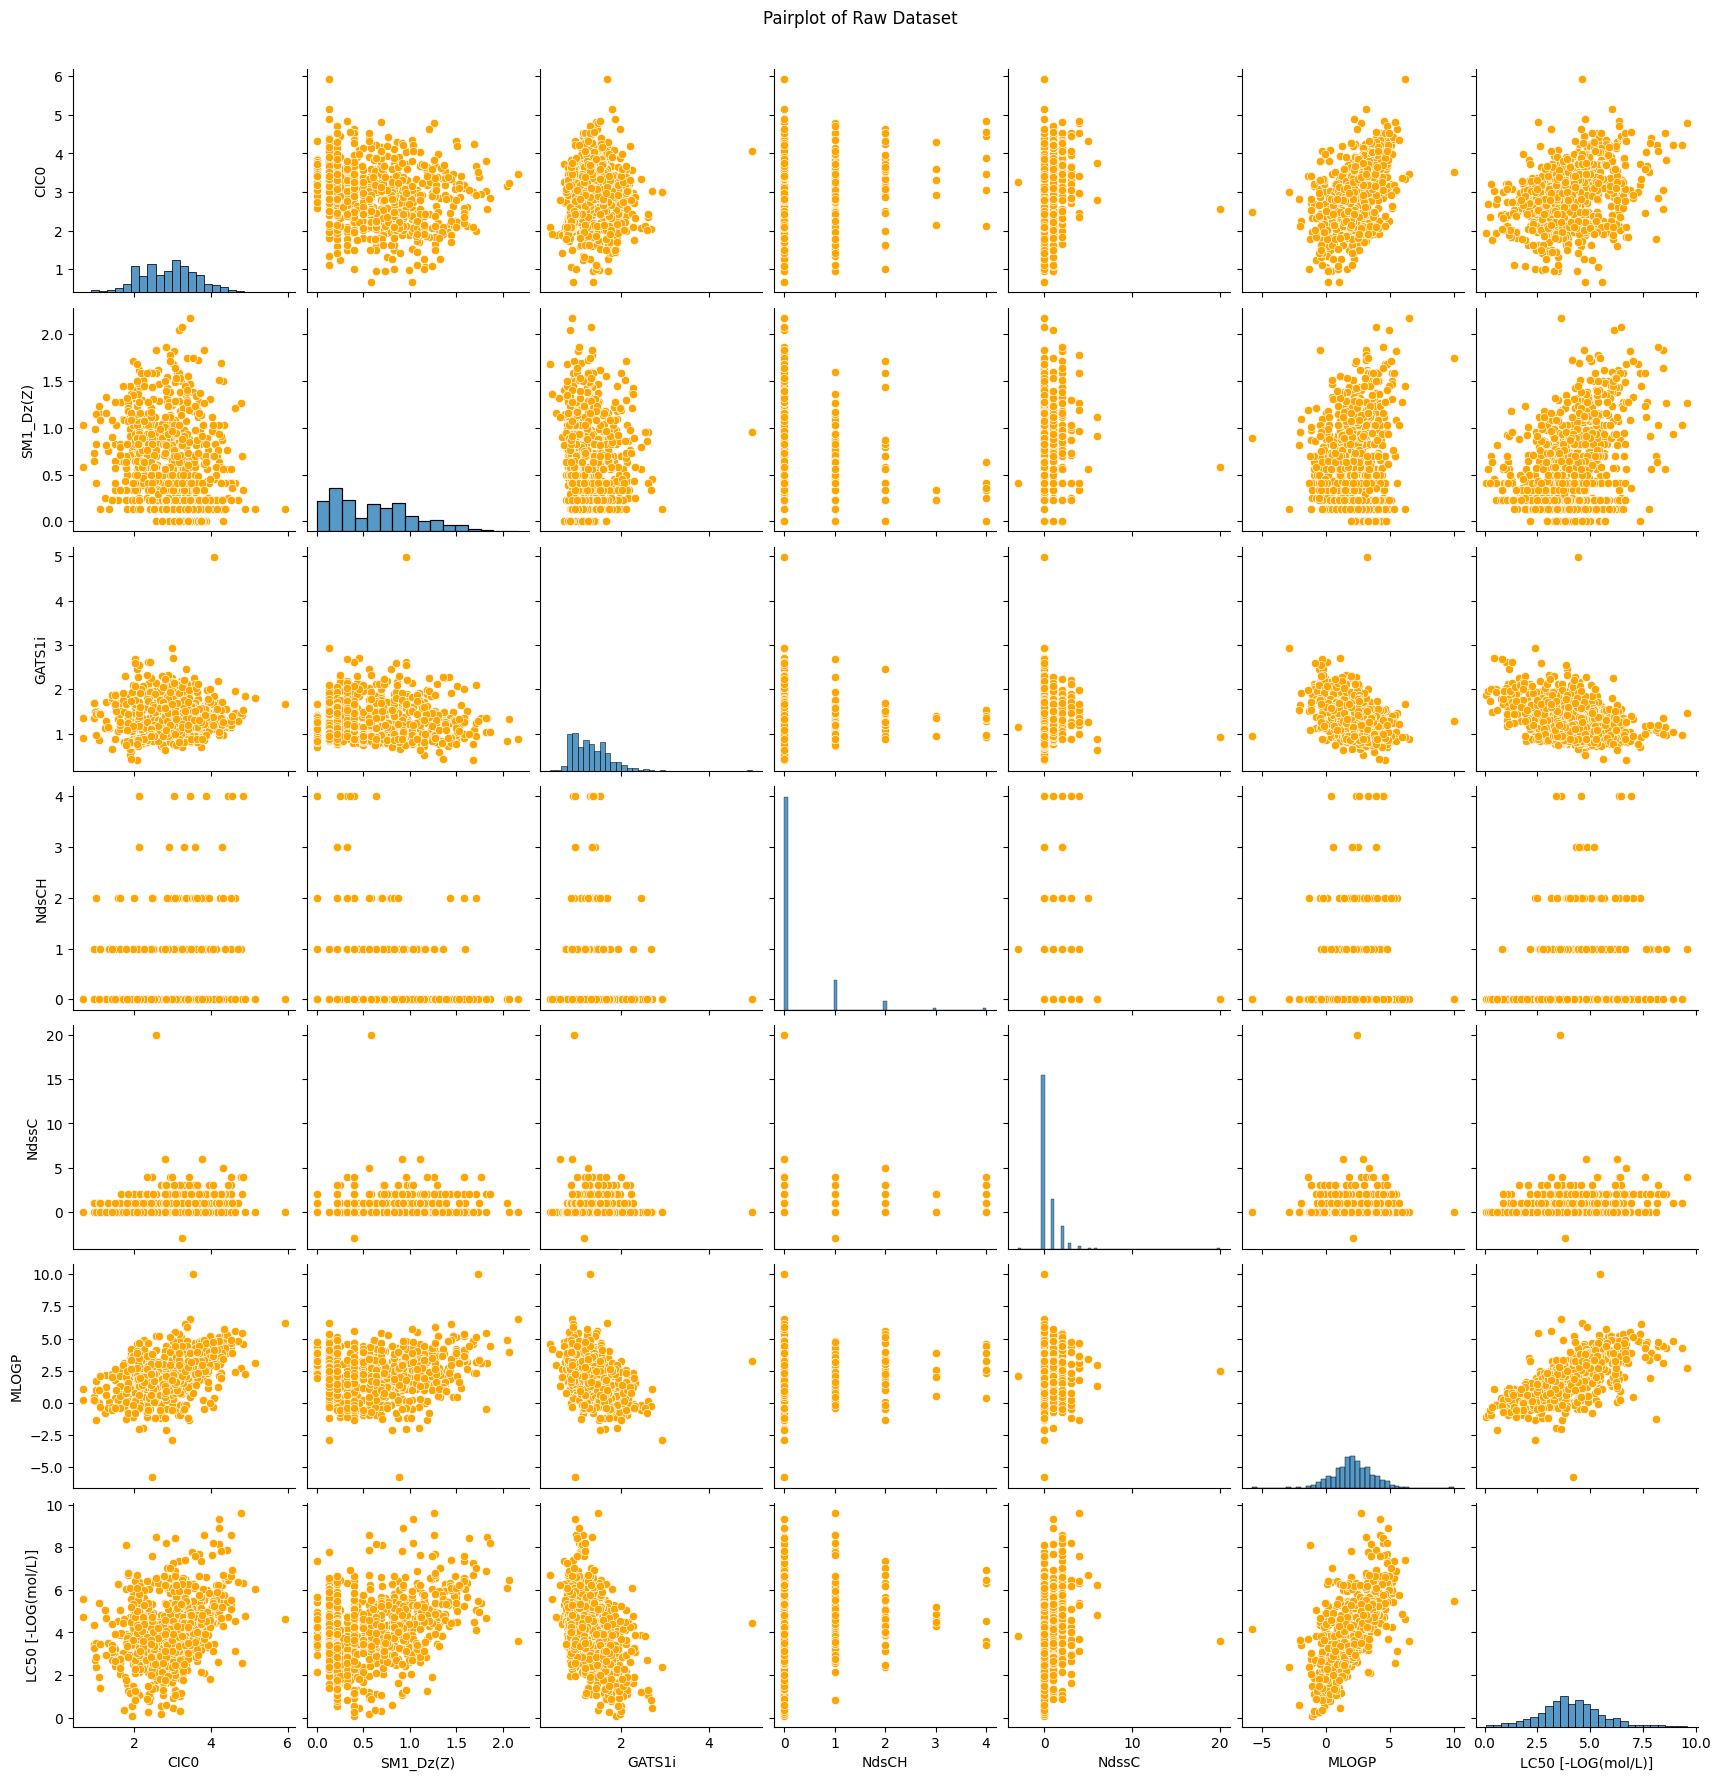

In [16]:
# Step 4: Visualization - Raw Dataset
sns.pairplot(df, diag_kind="hist", plot_kws={'color': 'orange'})
plt.suptitle("Pairplot of Raw Dataset", y=1.02)
plt.show()

In [17]:
# Step 5 & 6: Data Preprocessing and Cleaning
imputer = SimpleImputer(strategy="mean")
df_clean = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print("✅ Missing values filled.")

✅ Missing values filled.


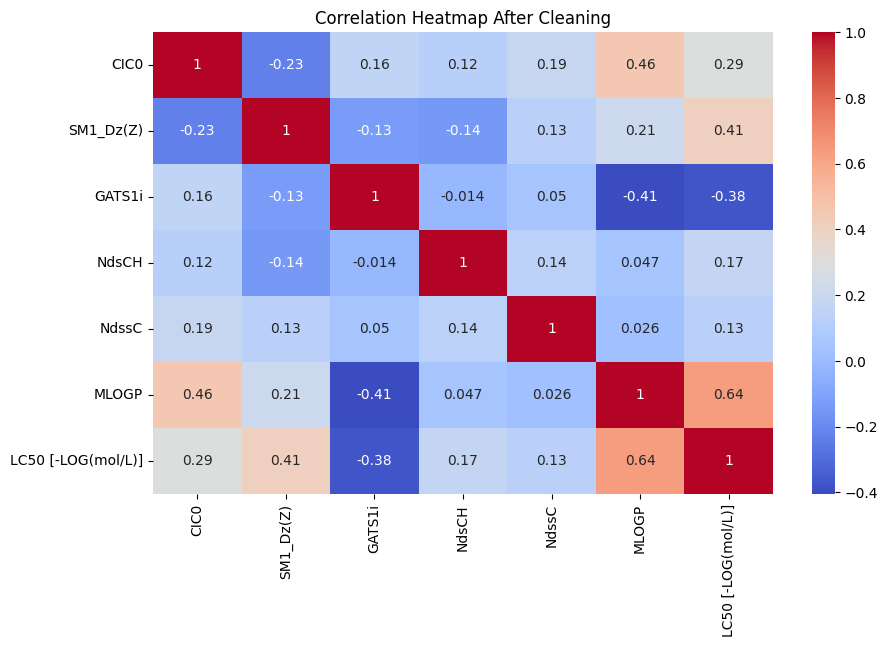

In [18]:
# Step 7: Visualization of Cleaned Data
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap After Cleaning")
plt.show()

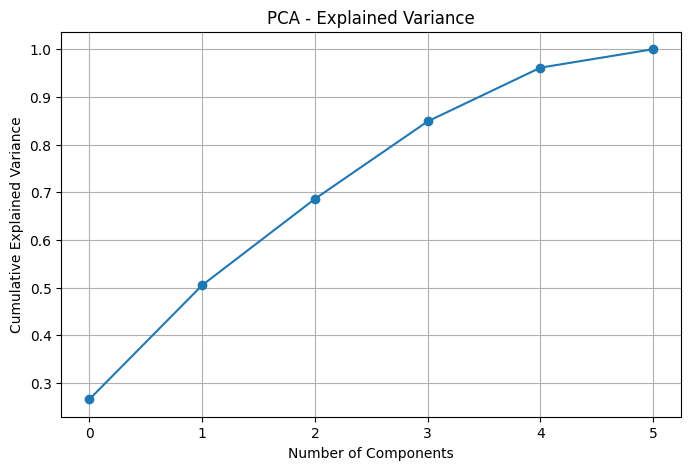

In [19]:
# Step 8: PCA Analysis
X = df_clean.drop("LC50 [-LOG(mol/L)]", axis=1)
y = df_clean["LC50 [-LOG(mol/L)]"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.grid(True)
plt.show()

In [20]:
# Step 9: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("✅ Train-test split done.")

✅ Train-test split done.


In [21]:
# Step 10: Model Training
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
print("✅ Models trained.")

✅ Models trained.


Linear Regression: MSE=1.0696, R²=0.5579
Random Forest: MSE=1.0415, R²=0.5695
SVR: MSE=0.9524, R²=0.6063
Gradient Boosting: MSE=1.0382, R²=0.5708


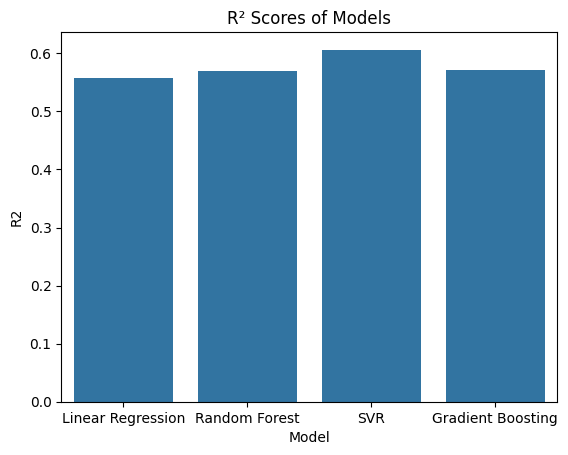

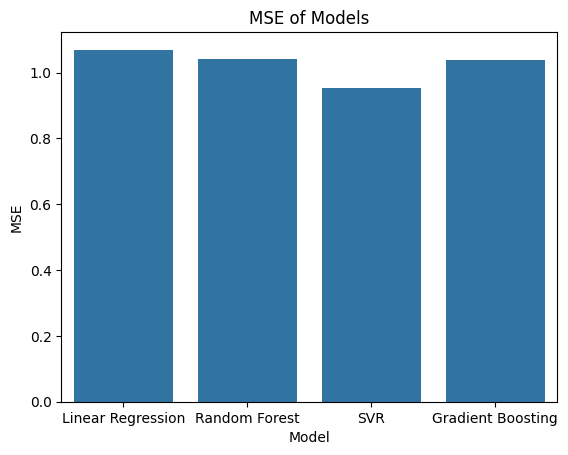

In [22]:
# Step 11-13: Evaluate and Compare
import pandas as pd
results = {"Model": [], "MSE": [], "R2": []}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    results["Model"].append(name)
    results["MSE"].append(mean_squared_error(y_test, y_pred))
    results["R2"].append(r2_score(y_test, y_pred))
    print(f"{name}: MSE={results['MSE'][-1]:.4f}, R²={results['R2'][-1]:.4f}")
results_df = pd.DataFrame(results)
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("R² Scores of Models")
plt.show()
sns.barplot(x="Model", y="MSE", data=results_df)
plt.title("MSE of Models")
plt.show()

Best RF Params: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 150}
Tuned RF - MSE: 1.0168920868163611
Tuned RF - R²: 0.5796342651484172


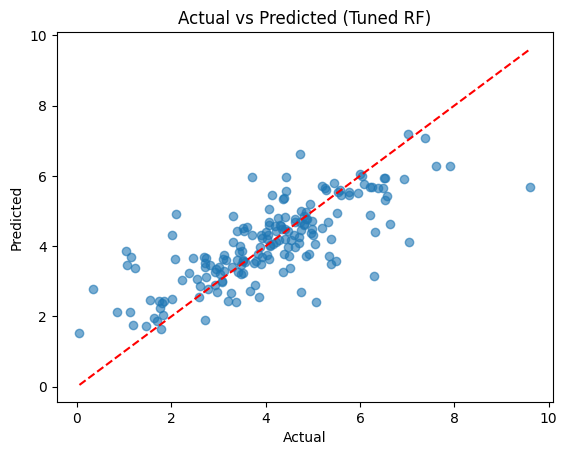

In [23]:
# Step 14-17: Tune Random Forest and Visualize
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [6, 8],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Best RF Params:", grid_search.best_params_)
print("Tuned RF - MSE:", mean_squared_error(y_test, y_pred_rf))
print("Tuned RF - R²:", r2_score(y_test, y_pred_rf))

plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted (Tuned RF)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Stacking R²: 0.5991347891928189


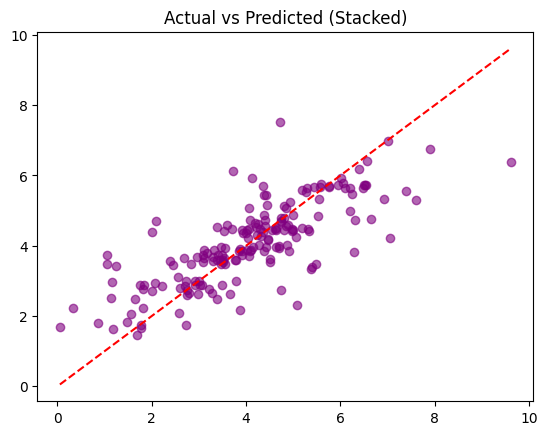

In [24]:
# Step 18-20: Ensemble - Stacking
stack = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('svr', SVR())
    ],
    final_estimator=GradientBoostingRegressor()
)
stack.fit(X_train, y_train)
y_pred_stack = stack.predict(X_test)
print("Stacking R²:", r2_score(y_test, y_pred_stack))
plt.scatter(y_test, y_pred_stack, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted (Stacked)")
plt.show()

In [25]:
# Step 21: Overfitting Check
train_pred = best_rf.predict(X_train)
print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, y_pred_rf))

Train R²: 0.8807812547835187
Test R²: 0.5796342651484172


SyntaxError: invalid character '🧠' (U+1F9E0) (434142383.py, line 7)